# Instruction Fine-Tuning the Pretrained GPT-124M Model

We will follow the below 9 steps grouped into 3 stages to instruction
fine-tune the GPT model which we created earlier:

**Stage 1 — Preparing the dataset**

1. Dataset download and formatting
2. Batching the dataset
3. Creating data loaders

**Stage 2 — Fine-tuning the LLM**

4. Loading a pretrained LLM
5. Instruction fine-tuning the LLM
6. Inspecting the modeling loss

**Stage 3 — Evaluating the LLM**

7. Extracting responses
8. Qualitative evaluation
9. Scoring the responses

**Note: Step 1 is adapted** rather than done from scratch: instead of downloading
and formatting a raw instruction dataset here, we load the already-formatted
`tinystories_alpaca_train.jsonl` produced earlier by `build_alpaca_dataset.py`.

### Setup & imports:

In [1]:
!pip install rouge-score -q

  Preparing metadata (setup.py) ... done


In [2]:
import os
import sys
import json
import random
import functools
import warnings
import inspect

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# -- Core ML --
import torch
import torch.nn as nn
import tiktoken
from transformers import AutoTokenizer
from importlib.metadata import version
torch.set_printoptions(sci_mode=False)
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

# -- Warning Control --
warnings.filterwarnings('ignore')  # suppress noisy library warnings (e.g. deprecation notices)

SEED = 1337
torch.manual_seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -- Tokenizer Setup --
# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
print(tokenizer.eos_token)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token by default; reuse eos_token
PAD_TOKEN_ID = tokenizer.pad_token_id

# -- Version Check --
print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))
print("transformers version:", version("transformers"))
print("datasets version:", version("datasets"))
print("safetensors version:", version("safetensors"))

Using device: cuda


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

<|endoftext|>
torch version: 2.11.0+cu128
tiktoken version: 0.13.0
transformers version: 5.13.1
datasets version: 4.0.0
safetensors version: 0.8.0


# Stage 1 —  Loading the Alpaca prompt style dataset

Instead of downloading and formatting a raw instruction dataset here, we
load the already-formatted `tinystories_alpaca_train.jsonl` produced
earlier by `build_alpaca_dataset.py`, then format each entry into the
Alpaca prompt style.

## 1. Dataset download and formatting

In [3]:
# Optional: browse and upload the dataset file from your local machine.
# Skip automatically if the file already exists at DATASET_PATH (e.g. same
# Colab session that ran build_alpaca_dataset.py, or a cloned repo), or if
# this isn't running in Colab at all.
DATASET_PATH = "../training/gpt/sft_data/tinystories_alpaca_train_sample.jsonl"
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(DATASET_PATH):
    print("Select tinystories_alpaca_train.jsonl to upload:")
    uploaded = files.upload()
    uploaded_filename = next(iter(uploaded))
    os.makedirs(os.path.dirname(DATASET_PATH) or ".", exist_ok=True)
    os.rename(uploaded_filename, DATASET_PATH)
    print(f"Uploaded and saved to {DATASET_PATH}")
elif os.path.exists(DATASET_PATH):
    print(f"Found existing file at {DATASET_PATH} — skipping upload.")
else:
    print("Not running in Colab and file not found — place the file manually "
          "or update DATASET_PATH to point at it.")

Select tinystories_alpaca_train.jsonl to upload:


Saving tinystories_alpaca_train_sample.jsonl to tinystories_alpaca_train_sample.jsonl
Uploaded and saved to ../training/gpt/sft_data/tinystories_alpaca_train_sample.jsonl


In [4]:

def load_jsonl(path):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return data

if os.path.exists(DATASET_PATH):
    data = load_jsonl(DATASET_PATH)
    print(f"Loaded {len(data)} examples from {DATASET_PATH}")
else:
    print(f"{DATASET_PATH} not found !")


Loaded 3991 examples from ../training/gpt/sft_data/tinystories_alpaca_train_sample.jsonl


In [5]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )
    return instruction_text + input_text

# Test on one entry with an Input field
with_input_entry = next((e for e in data if e.get("input", "").strip()), None)
assert with_input_entry is not None, "No entry with a non-empty input field found in this dataset"

model_input = format_input(with_input_entry)
desired_response = f"\n\n### Response:\n{with_input_entry['output']}"
print(model_input + desired_response)

print('\n\n')

# Test on an entry without an Input field — the ### Input: section should
# be skipped entirely, not left blank
no_input_entry = next((e for e in data if not e.get("input", "").strip()), data[0])
print(format_input(no_input_entry) + f"\n\n### Response:\n{no_input_entry['output']}")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Continue the following children's story in a natural and coherent way.

### Input:
Once upon a time, there was a boy named Pete. He was very little, only three years old! While playing outside, Pete got very sleepy. So, he settled in the grass and decided to take a nap. While Pete was napping, a rude boy came and tried

### Response:
to wake him up. But Pete's body was too heavy and the rude boy couldn't wake him. Eventually, Pete woke up. He smiled and rubbed his eyes, then he sat up and asked the rude boy why he was trying to wake him. The boy said he just wanted to play. Pete smiled, said he was tired and suggested the boy take a nap too! The two boys cuddled up together and took a nap in the sun. When they woke up, Pete and the rude boy were best friends. From then on, the two boys would always take a nap together after they played!



Below is an instruction 

Before we move on to setting up the PyTorch data loaders in the next
section, let's divide the dataset into training, validation, and test sets.

In [6]:
TRAIN_FRAC, VAL_FRAC = 0.85, 0.10  # remainder (0.05) goes to test

n = len(data)
n_train = int(n * TRAIN_FRAC)
n_val = int(n * VAL_FRAC)

train_data = data[:n_train]
val_data = data[n_train:n_train + n_val]
test_data = data[n_train + n_val:]

print(f"train: {len(train_data)} | val: {len(val_data)} | test: {len(test_data)}")
assert len(train_data) + len(val_data) + len(test_data) == n

train: 3392 | val: 399 | test: 200


## 2. Batching the dataset

In [7]:

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        self.prompt_lengths = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_marker = "\n\n### Response:\n"
            response_text = response_marker + entry["output"]
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))
            self.prompt_lengths.append(len(tokenizer.encode(instruction_plus_input + response_marker)))

    def __getitem__(self, index):
        return self.encoded_texts[index], self.prompt_lengths[index]

    def __len__(self):
        return len(self.data)

In [8]:
# Quick check against our own data
train_dataset = InstructionDataset(train_data, tokenizer)
print("Number of training entries:", len(train_dataset))
print("First entry (token ids):", train_dataset[0][:20], "...")

Number of training entries: 3392
First entry (token ids): ([21106, 318, 281, 12064, 326, 8477, 257, 4876, 13, 19430, 257, 2882, 326, 20431, 32543, 262, 2581, 13, 198, 198, 21017, 46486, 25, 198, 16594, 257, 1790, 1751, 338, 1621, 326, 3407, 262, 1708, 2456, 25, 2460, 11, 640, 13, 198, 198, 21017, 18261, 25, 198, 7454, 2402, 257, 640, 11, 612, 547, 734, 1266, 2460, 13, 1119, 547, 20037, 290, 8049, 13, 198, 198, 31087, 531, 284, 20037, 11, 366, 5211, 345, 765, 284, 1282, 284, 616, 2151, 1701, 220, 198, 198, 43, 813, 13541, 290, 531, 11, 366, 5297, 11, 314, 466, 0, 1680, 314, 2222, 616, 1545, 4186, 30, 679, 318, 257, 922, 1545, 1165, 526, 198, 198, 31087, 41723, 329, 257, 2589, 11, 366, 40, 836, 470, 892, 523, 13, 775, 836, 470, 423, 881, 2057, 11, 290, 4186, 1244, 407, 651, 1576, 526, 220, 198, 198, 1, 2504, 338, 20363, 553, 8712, 20037, 13, 366, 40, 4313, 326, 356, 14037, 4186, 1165, 526, 198, 198, 31087, 1807, 546, 428, 290, 673, 4987, 13, 1375, 531, 11, 366, 18690, 11, 1309, 338, 1577

### Padding and masking each batch: `custom_collate_fn`

`InstructionDataset` above only tokenizes each entry individually — it
doesn't pad or build training targets. That happens here, once PyTorch's
`DataLoader` groups individual entries into a batch: `custom_collate_fn` is
the function that turns a list of variable-length token sequences into one
padded, mask-aware tensor pair (`inputs`, `targets`).

In [9]:
def custom_collate_fn(batch, pad_token_id, ignore_index=-100, allowed_max_length=None, device="cpu"):
    """
    batch: list of (token_ids, prompt_len) tuples, as returned by InstructionDataset.

    Builds padded (input, target) tensors for next-token prediction, with
    TWO masks applied to the targets:
      1. The instruction/input portion — the model sees it as context but is
         never asked to "predict" it.
      2. All padding positions except the first — keeps exactly one
         "predict end-of-text" target trainable per example, so the model
         still learns when to stop generating, without wasting loss on
         repeated padding tokens.
    """
    # +1 so every example has room to build a shifted target for its last real token
    batch_max_length = max(len(ids) for ids, _ in batch) + 1

    inputs_lst, targets_lst = [], []

    for token_ids, prompt_len in batch:
        # Append one pad token so the last real token has a "next token" to
        # predict, then right-pad the rest up to this batch's longest example
        padded_ids = token_ids + [pad_token_id]
        padded_ids += [pad_token_id] * (batch_max_length - len(padded_ids))

        input_ids = torch.tensor(padded_ids[:-1])   # model input
        target_ids = torch.tensor(padded_ids[1:])   # next-token targets (shifted by 1)

        # --- Mask 1: instruction/input portion ---
        # target_ids[i] predicts padded_ids[i+1]. Masking up to prompt_len-1
        # (not prompt_len) is deliberate: target index prompt_len-1 is the
        # one predicting the FIRST response token — that's exactly what we
        # want the model trained on, so it stays unmasked.
        target_ids[:prompt_len - 1] = ignore_index

        # --- Mask 2: padding beyond the first pad position ---
        pad_positions = torch.nonzero(target_ids == pad_token_id, as_tuple=True)[0]
        if pad_positions.numel() > 1:
            target_ids[pad_positions[1:]] = ignore_index

        if allowed_max_length is not None:
            input_ids = input_ids[:allowed_max_length]
            target_ids = target_ids[:allowed_max_length]

        inputs_lst.append(input_ids)
        targets_lst.append(target_ids)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [10]:
sample_batch = [train_dataset[i] for i in range(3)]
inputs, targets = custom_collate_fn(sample_batch, pad_token_id=tokenizer.eos_token_id)

print("inputs shape: ", inputs.shape)
print("targets shape:", targets.shape)

for i in range(len(sample_batch)):
    n_masked = (targets[i] == -100).sum().item()
    n_trainable = (targets[i] != -100).sum().item()
    print(f"example {i}: {n_masked} masked, {n_trainable} trainable")

inputs shape:  torch.Size([3, 228])
targets shape: torch.Size([3, 228])
example 0: 48 masked, 180 trainable
example 1: 59 masked, 169 trainable
example 2: 105 masked, 123 trainable


## 3. Creating data loaders

Binds `pad_token_id`, `device`, and a max-length cap into `custom_collate_fn`
via `functools.partial`, so `DataLoader` can call it with just a batch of
examples. Wraps the train/val/test splits from Step 1 into `InstructionDataset`
instances, then into three separate `DataLoader`s.

In [11]:
NUM_WORKERS = 0
BATCH_SIZE = 8
ALLOWED_MAX_LENGTH = 1024  # setting it to model context length which is 1024 in this case.

customized_collate_fn = functools.partial(
    custom_collate_fn,
    pad_token_id=PAD_TOKEN_ID,
    allowed_max_length=ALLOWED_MAX_LENGTH,
    device=device,
)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, collate_fn=customized_collate_fn,
    shuffle=True, drop_last=True, num_workers=NUM_WORKERS,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, collate_fn=customized_collate_fn,
    shuffle=False, drop_last=False, num_workers=NUM_WORKERS,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, collate_fn=customized_collate_fn,
    shuffle=False, drop_last=False, num_workers=NUM_WORKERS,
)

print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)} | test batches: {len(test_loader)}")

train batches: 424 | val batches: 50 | test batches: 25


In [12]:
# Sanity check — pull one batch from each and confirm input/target shapes match
for name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    inputs, targets = next(iter(loader))
    print(f"{name}: inputs {inputs.shape}, targets {targets.shape}")

train: inputs torch.Size([8, 521]), targets torch.Size([8, 521])
val: inputs torch.Size([8, 394]), targets torch.Size([8, 394])
test: inputs torch.Size([8, 497]), targets torch.Size([8, 497])


# Stage 2 — Fine-tuning the LLM

## 4. Loading a pretrained LLM

Let's load the pretrained model weights which we got from pretraining our
own GPT-124M model in `train_gpt.py`. Note that we *could* instead load the
official GPT-2 weights directly (e.g. via `transformers.GPT2LMHeadModel` or
a Karpathy/Raschka-style conversion script) — that's a common shortcut when
you don't have your own pretrained checkpoint. Here, though, we already
have our own pretrained model, so we'll fine-tune that instead.

In [13]:
# Let's load the pretrained model weights which we got from pretraining our
# own GPT-124M model in `train_gpt.py`. Note that we *could* instead load the
# official GPT-2 weights directly (e.g. via `transformers.GPT2LMHeadModel` or
# Karpathy/Raschka-style conversion scripts) — that's a common shortcut when
# we don't have our own pretrained checkpoint. Here, though, we already
# have our own pretrained model, so we'll fine-tune that instead.
CHECKPOINT_PATH = "../training/gpt/checkpoints/ckpt_epoch001.pt"

In [14]:
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(CHECKPOINT_PATH):
    print("Select your pretrained checkpoint (ckpt_epochNNN.pt) to upload:")
    uploaded = files.upload()
    uploaded_filename = next(iter(uploaded))
    os.makedirs(os.path.dirname(CHECKPOINT_PATH) or ".", exist_ok=True)
    os.rename(uploaded_filename, CHECKPOINT_PATH)
    print(f"Uploaded and saved to {CHECKPOINT_PATH}")
elif os.path.exists(CHECKPOINT_PATH):
    print(f"Found existing checkpoint at {CHECKPOINT_PATH}")
else:
    print("Not running in Colab and checkpoint not found — place it manually "
          "or update CHECKPOINT_PATH.")

Select your pretrained checkpoint (ckpt_epochNNN.pt) to upload:


Saving ckpt_weights_only.pt to ckpt_weights_only.pt
Uploaded and saved to ../training/gpt/checkpoints/ckpt_epoch001.pt


### Initializing the GPT architecture

Before we can load pretrained weights into anything, we need an instance of
the model architecture itself — the same `GPTModel` class built from
scratch in `train_gpt.py` (custom `MultiHeadAttention`, `FeedForward`,
`LayerNorm`, weight tying, GPT-2-style init, etc.). Instantiating it here
just allocates the architecture with randomly initialized weights; the
pretrained weights get loaded into it next.

In [15]:
from torch.nn import functional as F


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduces the projection dim to match the desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)  # Uses a Linear layer to combine head outputs
        self.out_proj.NANOGPT_SCALE_INIT = 1

        self.dropout = dropout  # stored as a float, passed directly to F.scaled_dot_product_attention

        # NOTE: no register_buffer("mask", ...) needed here — is_causal=True below
        # handles causal masking internally, more efficiently than a manual mask tensor.

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Split into heads: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)

        # Required: transpose to (b, num_heads, num_tokens, head_dim) — scaled_dot_product_attention
        # expects the last two dims to be (seq_len, head_dim), with everything before treated as
        # batch dims. Without this transpose, num_tokens would be misread as a batch dim and
        # num_heads as the sequence dim, silently computing attention over the wrong axis.
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # FlashAttention / SDPA — fused, memory-efficient attention kernel
        context_vec = F.scaled_dot_product_attention(
            queries, keys, values,
            dropout_p=(self.dropout if self.training else 0.0),
            is_causal=True
        )

        # Re-assemble all head outputs side by side: (b, num_heads, num_tokens, head_dim) -> (b, num_tokens, d_out)
        context_vec = context_vec.transpose(1, 2).contiguous().view(b, num_tokens, self.d_out)

        context_vec = self.out_proj(context_vec)  # optional linear projection

        return context_vec

In [16]:
class LayerNorm(torch.nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = torch.nn.Parameter(torch.ones(emb_dim))
        self.shift = torch.nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)               # per-token mean, across embedding dim
        var = x.var(dim=-1, keepdim=True, unbiased=False)  # per-token variance, across embedding dim
        norm_x = (x - mean) / torch.sqrt(var + self.eps)   # normalize to zero mean, unit variance
        return self.scale * norm_x + self.shift            # learnable rescale + shift

In [17]:
class FeedForward(torch.nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_fc = nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"])    # expand: emb_dim -> 4x emb_dim
        self.gelu = nn.GELU(approximate='tanh')                      # non-linearity (GPT-2 style approximation)
        self.c_proj = nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])  # project back: 4x emb_dim -> emb_dim

        # Marker attribute (nanoGPT convention, credit: Andrej Karpathy) — flags this layer
        # for scaled-down weight initialization later, same reasoning as out_proj in
        # MultiHeadAttention: residual-stream output projections get reduced-variance init
        # to keep activations stable across deep transformer stacks.
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x

In [18]:
class TransformerBlock(torch.nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut/Residual connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back (residual connection)

        # Shortcut/Residual connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back (residual connection)

        return x

In [19]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg  # stored for access inside _init_weights (needs cfg["n_layers"])

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])       # token embeddings
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])   # positional embeddings
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)  # project to vocab logits

        # Weight tying: reuse the token embedding weights as the output layer weights,
        # matching the original GPT-2 architecture and reducing total parameter count.
        self.tok_emb.weight = self.out_head.weight

        # Apply custom weight initialization to every submodule
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """
        Custom weight initialization, following GPT-2 / nanoGPT conventions
        (credit: Andrej Karpathy's nanoGPT for the NANOGPT_SCALE_INIT scaling scheme).

        - std=0.02 approximates Xavier initialization (1/sqrt(fan_in)) for typical
          layer sizes in this model; a simple, fixed constant across all layers.
        - Residual-stream output projections (attn.out_proj, ff.c_proj) are flagged
          with NANOGPT_SCALE_INIT and get an additional scale-down by (2*n_layers)^-0.5,
          to counteract activation variance compounding across stacked residual blocks.
        - Biases are explicitly zero-initialized, standard GPT-2/nanoGPT convention.
        """
        if isinstance(module, nn.Linear):
            std = 0.02
            # to compensate for standard deviation growth inside the residual stream —
            # controls the growth of activations inside the residual stream.
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.cfg["n_layers"]) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        tok_embeds = self.tok_emb(in_idx)                                        # [b, seq_len, emb_dim]
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))   # [seq_len, emb_dim]
        x = tok_embeds + pos_embeds                                              # broadcast add positional info

        x = self.drop_emb(x)
        x = self.trf_blocks(x)      # pass through all n_layers TransformerBlocks
        x = self.final_norm(x)
        logits = self.out_head(x)   # [b, seq_len, vocab_size]

        return logits

    def configure_optimizers(self, weight_decay, learning_rate, device_type):
        """
        Builds an AdamW optimizer with GPT-3-style parameter grouping:
        - 2D+ parameters (Linear/Embedding weight matrices) get weight decay.
        - 1D parameters (biases, LayerNorm scale/shift) do not.
        Uses the fused AdamW kernel when available on CUDA, for faster training.
        """
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}

        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]

        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")

        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == "cuda"
        print(f"using fused AdamW: {use_fused}")

        optimizer = torch.optim.AdamW(
            optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused
        )
        return optimizer

In [20]:
GPT_CONFIG_124M = {
"vocab_size": 50304, # Vocabulary size,
"context_length": 1024, # Context length
"emb_dim": 768, # Embedding dimension
"n_heads": 12, # Number of attention heads
"n_layers": 12, # Number of layers
"drop_rate": 0.1, # Dropout rate
"qkv_bias": False # Query-Key-Value bias
}

model = GPTModel(GPT_CONFIG_124M)

if CHECKPOINT_PATH is not None and os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded pretrained checkpoint: {CHECKPOINT_PATH} "
          f"(epoch {checkpoint.get('epoch')}, step {checkpoint.get('step')})")

    weights_only = {"model_state_dict": checkpoint["model_state_dict"]}
else:
    print("No checkpoint found — using randomly initialized weights "
          "(only appropriate for pipeline testing, not a real fine-tuning run).")

model.to(device)

Loaded pretrained checkpoint: ../training/gpt/checkpoints/ckpt_epoch001.pt (epoch None, step None)


GPTModel(
  (tok_emb): Embedding(50304, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (ff): FeedForward(
        (c_fc): Linear(in_features=768, out_features=3072, bias=True)
        (gelu): GELU(approximate='tanh')
        (c_proj): Linear(in_features=3072, out_features=768, bias=True)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_

Before fine-tuning, let's see what the model produces on one example as-is
— this is the baseline we'll compare against once fine-tuning is done.

### Helper Functions

In [21]:
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text)
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # remove batch dimension
  return tokenizer.decode(flat.tolist())


def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (B, T) array of indices in the current context
    for _ in range(max_new_tokens):
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on the last time step
        # (batch, n_token, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Get the idx of the vocab entry with the highest logits value
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [22]:
def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=50):
    model.eval()
    raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model  # unwrap torch.compile
    context_size = raw_model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=max_new_tokens, context_size=context_size
        )
        decoded_text = token_ids_to_text(token_ids, tokenizer)
        print(decoded_text.replace("\n", " "))

    model.train()

In [23]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model, device)
        total_loss += loss.item()
    return total_loss / num_batches


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [24]:
import math

def get_lr(it, max_steps, warmup_steps, max_lr=6e-4):
    """
    Cosine learning rate schedule with linear warmup.
    Credit: this is the classic nanoGPT / GPT-3 style LR schedule.

    Args:
        it: current training step (0-indexed)
        max_steps: total number of training steps
        warmup_steps: number of initial steps to linearly ramp up the LR
        max_lr: peak learning rate, reached at the end of warmup

    Returns:
        The learning rate to use at this step.
    """
    min_lr = max_lr * 0.1

    # 1) Linear warmup for warmup_steps steps
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps

    # 2) If it > max_steps, return min learning rate
    if it > max_steps:
        return min_lr

    # 3) In between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))  # coeff starts at 1, decays to 0
    return min_lr + coeff * (max_lr - min_lr)

In [25]:
def print_memory_usage():
    if not torch.cuda.is_available():
        print("This notebook is intended for CUDA GPUs but CUDA is not available.")
        return
    device_name = torch.cuda.get_device_name(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory
    print(f"Device Name: {device_name}")
    print(f"Total Memory available: {total_memory / (1024**3):.2f} GB")
    max_gpu_memory = torch.cuda.max_memory_allocated() / (1024 ** 3)  # Convert bytes to GB
    print(f"Maximum GPU memory allocated: {max_gpu_memory:.1f} GB")

### Capturing before-fine-tuning responses

Before fine-tuning, let's generate the model's response on every held-out
test example as-is — this becomes the baseline we compare against later,
both qualitatively (Step 8) and quantitatively via ROUGE (Step 9).

`generate_text_with_eos` stops generation as soon as the model predicts the
EOS token, rather than always running the full `max_new_tokens` — important
for evaluation, since otherwise every response would be padded out with
repeated/degenerate trailing text past its natural stopping point.

`extract_responses` is written once here and reused again, unchanged, in
Step 7 — the only difference between "before" and "after" is which
`response_key` it's told to write results under and whether it runs before
or after Step 5's training loop.

In [26]:
from tqdm.auto import tqdm

def generate_text_with_eos(model, idx, max_new_tokens, context_size, eos_id=None):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next.item() == eos_id:
            break  # stop generating early once EOS is produced

        idx = torch.cat((idx, idx_next), dim=1)
    return idx


def extract_responses(model, data, tokenizer, device, context_size, response_key, max_new_tokens=256):
    model.eval()
    for entry in tqdm(data, desc=f"Generating ({response_key})"):
        prompt = format_input(entry) + "\n\n### Response:\n"
        input_ids = text_to_token_ids(prompt, tokenizer).to(device)
        with torch.no_grad():
            token_ids = generate_text_with_eos(
                model=model, idx=input_ids,
                max_new_tokens=max_new_tokens, context_size=context_size,
                eos_id=tokenizer.eos_token_id,
            )
        generated_text = token_ids_to_text(token_ids, tokenizer)
        entry[response_key] = generated_text[len(prompt):].strip()
    model.train()
    return data

In [27]:
test_data = extract_responses(
    model, test_data, tokenizer, device,
    context_size=GPT_CONFIG_124M["context_length"],
    response_key="before_finetune_response",
)
print(f"Captured before-fine-tuning responses for all {len(test_data)} test entries.")

Generating (before_finetune_response):   0%|          | 0/200 [00:00<?, ?it/s]

Captured before-fine-tuning responses for all 200 test entries.


In [28]:
model.eval()

baseline_entry = test_data[0]
prompt = format_input(baseline_entry) + "\n\n### Response:\n"

input_ids = text_to_token_ids(prompt, tokenizer).to(device)

with torch.no_grad():
    token_ids = generate_text_simple(
        model=model, idx=input_ids,
        max_new_tokens=50, context_size=GPT_CONFIG_124M["context_length"]
    )

generated_text = token_ids_to_text(token_ids, tokenizer)
before_finetune_response = generated_text[len(prompt):].strip()

print("Instruction:", baseline_entry["instruction"])
print("Input:      ", baseline_entry["input"])
print()
print("Model response (BEFORE fine-tuning):")
print(before_finetune_response)
print()
print("Reference output:")
print(baseline_entry["output"])

Instruction: Write a short children's story that includes the following words: world, little.
Input:       

Model response (BEFORE fine-tuning):
The children are all very excited to learn.

The moral of the story is that if you write a question, you can learn something new.<|endoftext|>Once upon a time, there was a little girl named Lucy. She was three years old

Reference output:
Once there was a little boy named Josh. He was three years old and he loved to explore the world. He loved to follow the birds, explore the garden and run around in the park.

One day, Josh saw a brown rabbit. He wanted to follow the rabbit and see where it went. So he slowly walked after the rabbit, being careful not to scare it away. The rabbit hopped away until it came to a burrow in the ground.

Josh wanted to give the rabbit a name, so he called out, "Hello, Mr Brown Rabbit!" He smiled as he said the name and the rabbit turned around and hopped off, disappearing into the burrow. Josh laughed and waved g

## 5. Instruction fine-tuning the LLM

### Loss function

Same next-token cross-entropy loss as pretraining, adapted for the
`(input_batch, target_batch)` tuple shape `custom_collate_fn`/`DataLoader`
now produce. No `ignore_index` argument needed — `-100` is already
PyTorch's default for `F.cross_entropy`, which is exactly what our masked
instruction and padding positions were set to.

In [29]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = F.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [30]:
# Sanity check on one real batch from train_loader, val_loader
input_batch, target_batch = next(iter(train_loader))
loss = calc_loss_batch(input_batch, target_batch, model, device)
print("Loss on one training batch:", loss.item())

input_batch, target_batch = next(iter(val_loader))
loss = calc_loss_batch(input_batch, target_batch, model, device)
print("Loss on one validation batch:", loss.item())

Loss on one training batch: 1.5526689291000366
Loss on one validation batch: 1.6770482063293457


### Instruction fine-tuning hyperparameters

Instruction fine-tuning uses a much lower learning rate than pretraining
(here 3e-5 vs. `train_gpt.py`'s 6e-4 default) and far fewer epochs, since
the goal is nudging the model's behavior toward following instructions, not
re-learning language from scratch.

In [31]:
LEARNING_RATE = 3e-5
WEIGHT_DECAY = 0.1
WARMUP_STEPS = 5
NUM_EPOCHS = 2
GRAD_CLIP_NORM = 1.0

optimizer = model.configure_optimizers(
    weight_decay=WEIGHT_DECAY, learning_rate=LEARNING_RATE, device_type=device.type
)

steps_per_epoch = len(train_loader)
num_training_steps = NUM_EPOCHS * steps_per_epoch
print(f"steps/epoch: {steps_per_epoch} | total training steps: {num_training_steps}")

num decayed parameter tensors: 74, with 124,354,560 parameters
num non-decayed parameter tensors: 86, with 93,696 parameters
using fused AdamW: True
steps/epoch: 424 | total training steps: 848


### The training loop

Adapted from `train_gpt.py`'s pretraining loop — same cosine LR schedule,
gradient clipping, tokens/sec throughput tracking, and periodic memory/
sample-generation diagnostics. Two changes from the pretraining version:

1. **Batch unpacking**: pretraining's dataloader yields a dict
   (`batch['input_ids']`, `batch['target_ids']`), since it uses HF
   `datasets` with `.set_format("torch")`. `custom_collate_fn` instead
   returns a plain tuple, so batches are unpacked directly:
   `input_batch, target_batch = batch`.
2. **Sample prompt is instruction-formatted**: `start_context` is passed
   through `format_input(...)` rather than a bare continuation string, so
   the periodic sample generation actually shows whether the model is
   learning to follow the instruction format — not just producing plausible
   prose.

In [32]:
from tqdm.auto import tqdm
import time

def train_model(model, train_loader, val_loader, optimizer, device, num_epochs,
                 eval_freq, eval_iter, start_context, tokenizer, max_new_tokens,
                 warmup_steps=10, max_lr=3e-05):
    train_losses, val_losses, track_tokens, track_epochs = [], [], [], []
    total_tokens, global_step, last_tokens = 0, -1, 0

    num_training_steps = num_epochs * len(train_loader)
    device_type = device.type
    print(num_training_steps)

    cumulative_tokens, cumulative_time = 0.0, 0.0
    use_cuda = device.type == "cuda"
    if use_cuda:
        t_start = torch.cuda.Event(enable_timing=True)
        t_end = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        t_start.record()
    else:
        t0 = time.time()

    progress_bar = tqdm(total=num_training_steps)

    for epoch in range(num_epochs):
        model.train()
        print_memory_usage()

        for batch in train_loader:
            optimizer.zero_grad()
            global_step += 1
            input_batch, target_batch = batch  # our loader yields a tuple, not a dict

            if use_cuda:
                with torch.autocast(device_type=device_type, dtype=torch.bfloat16):
                    loss = calc_loss_batch(input_batch, target_batch, model, device)
            else:
                loss = calc_loss_batch(input_batch, target_batch, model, device)

            loss.backward()

            # Clip gradients to prevent instability from occasional large-gradient batches
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Determine and set the learning rate for this step (cosine schedule w/ warmup)
            lr = get_lr(global_step, num_training_steps, warmup_steps, max_lr)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr

            optimizer.step()

            total_tokens += input_batch.numel()
            progress_bar.update(1)

            if global_step % eval_freq == 0 or global_step == num_training_steps - 1:
                if use_cuda:
                    t_end.record()
                    torch.cuda.synchronize()
                    elapsed = t_start.elapsed_time(t_end) / 1000
                    t_start.record()
                else:
                    elapsed = time.time() - t0
                    t0 = time.time()

                tokens_interval = total_tokens - last_tokens
                last_tokens = total_tokens
                tps = tokens_interval / elapsed if elapsed > 0 else 0

                if global_step:
                    cumulative_tokens += tokens_interval
                    cumulative_time += elapsed

                avg_tps = cumulative_tokens / cumulative_time if cumulative_time > 0 else 0

                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens.append(total_tokens)
                track_epochs.append(global_step / steps_per_epoch)

                print(f"Ep {epoch+1}, Step {global_step:06d} | Train loss: {train_loss:.3f} | "
                      f"Val loss: {val_loss:.3f} | norm: {norm:.4f} | LR: {lr:.6f} | "
                      f"Step tok/sec: {round(tps)} | Avg tok/sec: {round(avg_tps)}")

                generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens)
                print_memory_usage()

    return train_losses, val_losses, track_tokens, track_epochs

In [33]:
sample_prompt = format_input(train_data[0]) + "\n\n### Response:\n"  # instruction-formatted, not a bare continuation prompt
EVAL_FREQ = 200
EVAL_ITER = 200

train_losses, val_losses, track_tokens, track_epochs = train_model(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=NUM_EPOCHS, eval_freq=EVAL_FREQ, eval_iter=EVAL_ITER,
    start_context=sample_prompt, tokenizer=tokenizer, max_new_tokens=50,
    warmup_steps=WARMUP_STEPS, max_lr=LEARNING_RATE,
)

848


  0%|          | 0/848 [00:00<?, ?it/s]

Device Name: NVIDIA A100-SXM4-40GB
Total Memory available: 39.49 GB
Maximum GPU memory allocated: 7.4 GB
Ep 1, Step 000000 | Train loss: 1.579 | Val loss: 1.561 | norm: 5.6331 | LR: 0.000006 | Step tok/sec: 3506 | Avg tok/sec: 0
Below is an instruction that describes a task. Write a response that appropriately completes the request.  ### Instruction: Write a short children's story that includes the following words: friends, time.  ### Response:  The children are all very excited to learn.  The moral of the story is that it is important to be patient and to be patient.<|endoftext|>Once upon a time, there was a little girl named Lucy. She was three years old and
Device Name: NVIDIA A100-SXM4-40GB
Total Memory available: 39.49 GB
Maximum GPU memory allocated: 7.4 GB
Ep 1, Step 000200 | Train loss: 1.313 | Val loss: 1.367 | norm: 1.6710 | LR: 0.000027 | Step tok/sec: 26584 | Avg tok/sec: 26584
Below is an instruction that describes a task. Write a response that appropriately completes the 

## 6. Inspecting the modeling loss


In [34]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_values(epochs_seen, tokens_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plots training and validation values against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Creates a second x-axis for Tokens seen
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjusts layout to make room
    # plt.savefig(f"{label}-plot.pdf")
    # plt.show()

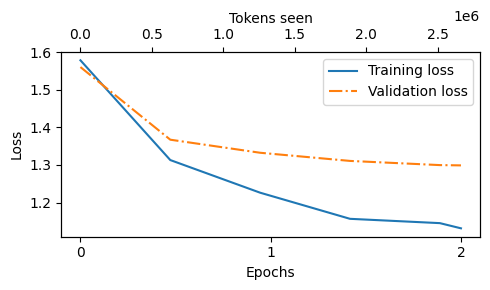

In [35]:
plot_values(track_epochs, track_tokens, train_losses, val_losses, label="loss")

# Stage 3 — Evaluating the LLM

## 7. Extracting responses

Runs the now fine-tuned model over the same held-out `test_data` set,
reusing the `extract_responses` helper from Step 4 — this time storing
results under `"model_response"` rather than `"before_finetune_response"`.

In [36]:
model.eval()

test_data = extract_responses(
    model, test_data, tokenizer, device,
    context_size=GPT_CONFIG_124M["context_length"],
    response_key="model_response",
)

Generating (model_response):   0%|          | 0/200 [00:00<?, ?it/s]

In [37]:
# Spot-check a couple of entries
for entry in test_data[:3]:
    print("Instruction:", entry["instruction"])
    print("Input:      ", entry["input"])
    print("Reference:  ", entry["output"])
    print()
    print("Model response:", entry["model_response"])
    print("-" * 40)

Instruction: Write a short children's story that includes the following words: world, little.
Input:       
Reference:   Once there was a little boy named Josh. He was three years old and he loved to explore the world. He loved to follow the birds, explore the garden and run around in the park.

One day, Josh saw a brown rabbit. He wanted to follow the rabbit and see where it went. So he slowly walked after the rabbit, being careful not to scare it away. The rabbit hopped away until it came to a burrow in the ground.

Josh wanted to give the rabbit a name, so he called out, "Hello, Mr Brown Rabbit!" He smiled as he said the name and the rabbit turned around and hopped off, disappearing into the burrow. Josh laughed and waved goodbye to his new friend.

Josh followed the rabbit's tracks back home, where he told his parents all about his adventure. His parents were so proud of him - Josh had made a new friend and seen what amazing things he could find when he followed his curiosity.

Mod

## 8. Qualitative evaluation

### Before vs. after, on one example

The clearest single piece of evidence that fine-tuning did something:
`test_data[0]`'s response before fine-tuning (captured in Step 4, from the
freshly-loaded pretrained model) against its response now, after Step 5's
training loop.

In [38]:
print("=== Before vs After Fine-Tuning: test_data[0] ===")
print("Instruction:", test_data[0]["instruction"])
if test_data[0]["input"]:
    print("Input:      ", test_data[0]["input"])
print("Reference:  ", test_data[0]["output"])
print()
print("BEFORE fine-tuning: \n", before_finetune_response)
print()
print("AFTER fine-tuning: \n", test_data[0]["model_response"])

=== Before vs After Fine-Tuning: test_data[0] ===
Instruction: Write a short children's story that includes the following words: world, little.
Reference:   Once there was a little boy named Josh. He was three years old and he loved to explore the world. He loved to follow the birds, explore the garden and run around in the park.

One day, Josh saw a brown rabbit. He wanted to follow the rabbit and see where it went. So he slowly walked after the rabbit, being careful not to scare it away. The rabbit hopped away until it came to a burrow in the ground.

Josh wanted to give the rabbit a name, so he called out, "Hello, Mr Brown Rabbit!" He smiled as he said the name and the rabbit turned around and hopped off, disappearing into the burrow. Josh laughed and waved goodbye to his new friend.

Josh followed the rabbit's tracks back home, where he told his parents all about his adventure. His parents were so proud of him - Josh had made a new friend and seen what amazing things he could find 

### Broader spot-check: random examples

Sampling randomly (rather than just the first few) avoids accidentally
reviewing only whichever examples happened to sort first after the Step 1
split.

In [39]:
def print_qualitative_results(data, n=5):
    for i, entry in enumerate(data[:n]):
        print(f"=== Example {i+1} ===")
        print("Instruction:", entry["instruction"])
        if entry["input"]:
            print("Input:      ", entry["input"])
        print("Reference:  ", entry["output"])
        print("Model:      ", entry["model_response"])
        print()

random_sample = random.sample(test_data, min(5, len(test_data)))
print_qualitative_results(random_sample, n=len(random_sample))

=== Example 1 ===
Instruction: Write a short children's story that includes the following words: snack, great.
Reference:   Once there was a little girl named Sarah. She loved to play and have fun. One day, Sarah went to the park with her friends. They played tag and bounced on the trampoline for hours. Sarah laughed and had a great time!

After the playtime, Sarah and her friends went for a snack. Sarah felt so happy, she knew she had been a success. She was so proud of herself!

When afternoon came, Sarah was very tired. She had bounced, ran and laughed all day. Her mom came to pick her up and gave Sarah a big hug. She said that Sarah had worked very hard, and it was time to go home and rest. 

As they drove away, Sarah smiled - she had had a wonderful day. And she knew she would have the energy to bounce again tomorrow!
Model:       Once upon a time, there was a little girl named Lily. She loved to eat snacks, especially cookies. One day, her mom made her a big plate of cookies. Lil

## 9. Scoring the responses

### ROUGE — before vs. after fine-tuning

No model download required, unlike an LLM-judge or `bert-score` approach —
fast, dependency-light overlap scoring between each response and its
reference `output`. Scoring both `before_finetune_response` and
`model_response` gives a quantitative version of the before/after
comparison above, across the whole test set rather than one example.

In [40]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

def score_responses(data, response_key, score_prefix):
    for entry in data:
        result = scorer.score(entry["output"], entry[response_key])
        entry[f"{score_prefix}_rouge1_f1"] = result["rouge1"].fmeasure
        entry[f"{score_prefix}_rougeL_f1"] = result["rougeL"].fmeasure
    return data

test_data = score_responses(test_data, "before_finetune_response", "before")
test_data = score_responses(test_data, "model_response", "after")

avg_before_rouge1 = sum(e["before_rouge1_f1"] for e in test_data) / len(test_data)
avg_after_rouge1 = sum(e["after_rouge1_f1"] for e in test_data) / len(test_data)
avg_before_rougeL = sum(e["before_rougeL_f1"] for e in test_data) / len(test_data)
avg_after_rougeL = sum(e["after_rougeL_f1"] for e in test_data) / len(test_data)

print(f"ROUGE-1 F1 — before: {avg_before_rouge1:.3f} | after: {avg_after_rouge1:.3f} | delta: {avg_after_rouge1 - avg_before_rouge1:+.3f}")
print(f"ROUGE-L F1 — before: {avg_before_rougeL:.3f} | after: {avg_after_rougeL:.3f} | delta: {avg_after_rougeL - avg_before_rougeL:+.3f}")

ROUGE-1 F1 — before: 0.167 | after: 0.373 | delta: +0.205
ROUGE-L F1 — before: 0.119 | after: 0.220 | delta: +0.101


### Optional: BERTScore (semantic similarity — needs real internet)

Requires downloading a pretrained model (~1.4GB) on first run. Works fine
in Colab; will hang with no output in network-restricted environments. Off
by default — flip `RUN_BERTSCORE` to `True` for a semantically-aware second
opinion on top of ROUGE.

In [41]:
RUN_BERTSCORE = False

if RUN_BERTSCORE:
    from bert_score import score as bert_score

    references = [entry["output"] for entry in test_data]
    candidates = [entry["model_response"] for entry in test_data]

    P, R, F1 = bert_score(candidates, references, lang="en", verbose=True)

    for entry, f1 in zip(test_data, F1):
        entry["bertscore_f1"] = f1.item()

    print(f"Average BERTScore F1: {F1.mean().item():.3f}")
else:
    print("Skipping BERTScore (RUN_BERTSCORE=False) — flip to True for a semantic-similarity second opinion.")

Skipping BERTScore (RUN_BERTSCORE=False) — flip to True for a semantic-similarity second opinion.


In [42]:
with open("instruction-data-with-response.json", "w") as f:
    json.dump(test_data, f, indent=4)

print(f"Saved {len(test_data)} scored entries to instruction-data-with-response.json")

Saved 200 scored entries to instruction-data-with-response.json


## Instruction Fine-Tuning a From-Scratch GPT-124M — What I Learned

Starting point: a GPT-124M model pretrained from scratch on TinyStories
(see the earlier post/notebook on that). This round: teaching it to follow
instructions rather than just continue text, using a small Alpaca-style
dataset built from TinyStories itself.


## What Actually Worked

- **Instruction-following format was learned successfully.** Before
  fine-tuning, the model had no concept of the instruction template at all
  — it ignored it and just kept generating unrelated text. After
  fine-tuning, every response is a coherent, on-topic attempt at the actual
  task.
- **ROUGE confirms it's not just a vibe** — ROUGE-1 F1 went from 0.167 to
  0.373, ROUGE-L F1 from 0.119 to 0.220, measured on a held-out test split
  the model never trained on.
- **Loss curve behaved exactly as expected** — smooth, converging train/val
  loss with no overfitting blowup, using a much lower learning rate and far
  fewer epochs than pretraining (the standard fine-tuning playbook).

A substantial, consistent improvement in overlap with reference responses on both metrics.

## Where It Still Falls Short

- **Keyword-constraint following is weak.** When asked to include specific
  required words, the model reliably works in one or two but almost never
  all of them.

  Root cause: standard fine-tuning loss has no discrete
  "constraint satisfied" signal — it only ever asks "how likely is the
  reference token here," which can't structurally guarantee inclusion of a
  specific word.
- **Mode collapse under greedy decoding.** Responses lean heavily toward
  the same character name and a repeating "ran into trouble → learned a
  lesson" plot shape. Likely a decoding-strategy artifact (greedy decoding
  always picks the single most probable token) more than a training
  problem — sampling-based decoding should reveal more real diversity.


## Scope for Improvement — What's Next

- **Better training data**: switch from the heuristic custom dataset to
  `TinyStoriesInstruct` — its `Words:` field was the actual generation
  constraint used to create each story, a stronger signal than words
  retrofitted onto an existing story.
- **Verify-and-regenerate at inference time**: check whether required
  keywords are actually present in a generated response, and resample if
  not — a cheap, no-retraining fix for the exact keyword-compliance gap
  above.
- **Preference optimization (DPO)** on top of this SFT checkpoint, using
  constraint satisfaction as the preference signal — the most principled
  fix, since it directly optimizes for something plain SFT loss can't
  express.
- **Scale**: some of this gap may simply be a 124M-parameter capacity
  ceiling, not something more data alone fully resolves.

The honest takeaway: fine-tuning clearly worked for what it's good at
(format, tone, fluency) and clearly has limits in exactly the place theory
predicts it would (precise constraint satisfaction) — which turned out to
be a more useful lesson than a clean success story would have been.